(observed_distributions)=
# 观测分布

```{index} single: Observed Distributions
```

## 概述

在关于 {doc}`概率分布 <prob_dist>` 的讲座中，我们研究了概率分布，这些是数学对象。

在本讲座中，我们转向观测数据——即我们测量或收集的一组数字。

我们将讨论如何总结和可视化这些数据，以及观测数据如何与概率分布联系起来。

第三讲 {doc}`fitting_distributions` 接着讨论哪个概率分布最适合描述给定的数据集这一问题。

In [1]:
!pip install --upgrade yfinance  

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import yfinance as yf
import scipy.stats
import seaborn as sns

np.set_printoptions(legacy='1.25')   # print scalars as plain numbers

有时我们将观测数据或测量结果称为"分布"。

例如，假设我们观察 10 个人一年的收入：

In [3]:
data = [['Hiroshi', 1200], 
        ['Ako', 1210], 
        ['Emi', 1400],
        ['Daiki', 990],
        ['Chiyo', 1530],
        ['Taka', 1210],
        ['Katsuhiko', 1240],
        ['Daisuke', 1124],
        ['Yoshi', 1330],
        ['Rie', 1340]]

df = pd.DataFrame(data, columns=['name', 'income'])
df

,name,income
0,Hiroshi,1200
1,Ako,1210
2,Emi,1400
3,Daiki,990
4,Chiyo,1530
5,Taka,1210
6,Katsuhiko,1240
7,Daisuke,1124
8,Yoshi,1330
9,Rie,1340


在这种情况下，我们可能会将他们的收入集合称为"收入分布"。

这一术语容易引起混淆，因为这个集合并不是概率分布——它只是一组数字的集合。

然而，正如我们将看到的，观测分布（即像上面的收入分布这样的数字集合）与概率分布之间存在联系。

下面我们来探讨一些观测分布。


## 样本矩

假设我们有一个观测分布，其值为 $\{x_1, \ldots, x_n\}$。

该分布的**样本均值**定义为

$$
\bar x = \frac{1}{n} \sum_{i=1}^n x_i
$$

**样本方差**定义为

$$
s^2 = \frac{1}{n} \sum_{i=1}^n (x_i - \bar x)^2
$$

而**样本标准差** $s$ 是其平方根。

对于上面给出的收入分布，我们可以通过以下方式计算这些数字

In [4]:
x = df['income']
x.mean(), x.var(), x.std()

(1257.4, 22680.93333333333, 150.6019034850932)

这些统计量中的每一个都是 {doc}`prob_dist` 中定义的总体量的样本对应值：我们用观测数据代替概率分布，对每个观测值赋予相同的权重。

同样的思想可以扩展到更高阶的矩。

**样本偏度**和**样本峰度**为

$$
\hat S = \frac{1}{n} \sum_{i=1}^n \left( \frac{x_i - \bar x}{s} \right)^3
\qquad \text{和} \qquad
\hat K = \frac{1}{n} \sum_{i=1}^n \left( \frac{x_i - \bar x}{s} \right)^4
$$

样本超额峰度为 $\hat K - 3$。

回想一下 {doc}`prob_dist` 中提到，正态分布的偏度为零，超额峰度为零。

这为我们提供了一种最初的、纯粹数值化的方法来判断一个数据集是否看起来符合正态分布。

让我们在美国成年女性身高数据上试一试，我们之前看到这些数据可以很好地用正态分布来描述。

In [5]:
url = ('https://github.com/QuantEcon/data-lectures/raw/main/'
       'lectures/us_adult_heights.csv')
heights = pd.read_csv(url)
female = heights[heights['sex'] == 'female']['height_cm']

scipy.stats.skew(female), scipy.stats.kurtosis(female)

(0.06940271585060076, -0.009473050923347603)

这两个数字都接近于零，这与我们在图中所看到的一致。

现在让我们来看一个远非正态分布的数据集。

下面的代码单元读取了 2006 年至 2010 年间在爱荷华州艾姆斯市（Ames）售出的 2,930 套房屋的销售价格，以及每套房屋的一些特征 {cite}`decock2011ames`。

In [6]:
url = ('https://github.com/QuantEcon/data-lectures/raw/main/'
       'lectures/ames_house_prices.csv')
houses = pd.read_csv(url)
houses.head()

,price,bedrooms,living_area_sqft,year_built,neighborhood
0,215000,3,1656,1960,NAmes
1,105000,2,896,1961,NAmes
2,172000,3,1329,1958,NAmes
3,244000,3,2110,1968,NAmes
4,189900,3,1629,1997,Gilbert


让我们计算销售价格的相同统计量。

In [7]:
price = houses['price']
scipy.stats.skew(price), scipy.stats.kurtosis(price)

(1.7426073719460107, 5.108121716933333)

偏度较大且为正，说明数据具有较长的右尾——少数房屋的售价远高于典型价格。

超额峰度也很大，说明极端值出现的频率远高于正态分布下的情形。

我们在 {doc}`prob_dist` 中查看对数正态分布时，正是看到了这种组合。

这提示我们应该取对数。

In [8]:
log_price = np.log(price)
scipy.stats.skew(log_price), scipy.stats.kurtosis(log_price)

(-0.014785864999287298, 1.509277466509812)

现在偏度几乎恰好为零。

换句话说，销售价格的*对数*看起来比销售价格本身更接近正态分布，这正是对数正态分布的定义性特征。

我们最后一个例子的情形正好相反。

下一个代码单元读取了 2023 年日本每个单岁年龄的死亡人数，数据来自联合国的[世界人口展望](https://population.un.org/wpp/)。

In [9]:
url = ('https://github.com/QuantEcon/data-lectures/raw/main/'
       'lectures/japan_deaths_by_age.csv')
deaths = pd.read_csv(url)
deaths.tail()

,age,deaths_male,deaths_female,deaths_total
96,96,9818,25563,35381
97,97,7652,22605,30258
98,98,5757,19343,25100
99,99,4197,15801,19998
100,100,8006,42277,50284


数据以计数的形式给出，因此我们将其展开为一个每次死亡对应一个观测值的数据集。

In [10]:
age_at_death = np.repeat(deaths['age'], deaths['deaths_total'])
len(age_at_death)

1524431

In [11]:
scipy.stats.skew(age_at_death), scipy.stats.kurtosis(age_at_death)

(-1.5993074774223388, 4.579170087851459)

现在偏度较大且为*负*。

死亡集中在高龄阶段，并向零方向延伸出一条长尾——与房价数据正好是镜像关系。

```{note}
最后一个年龄段被记录为"100 岁及以上"，因此所有 100 岁以上的死亡都被计为 100 岁。

这在日本并不是一个可以忽略的群体：它占所有死亡人数的 3.3%，占女性死亡人数的 5.7%。

我们将在下面的直方图中看到它以尖峰的形式出现在右端，这是数据记录方式造成的伪影，而非数据本身的特征。
```

```{exercise}
:label: obs_ex1

如果你尝试验证上面给出的样本均值和样本方差公式是否得出相同的数字，你会发现方差并不完全一致。这是因为 Pandas 在方差公式前使用的是 $1/(n-1)$ 而不是 $1/n$。（一些书籍就是这样定义样本方差的。）请确认这一点。
```

```{note}
偏度和峰度也存在同样的问题，不同的惯例会以不同的方式调整估计值。

Pandas 的方法 `x.skew()` 和 `x.kurt()` 应用了这类调整，因此它们与上面的公式并不完全一致，而 `scipy.stats.skew` 和 `scipy.stats.kurtosis` 使用的是纯粹的 $1/n$ 版本。

当 $n$ 较大时，这些差异很小。

还要记住，`scipy.stats.kurtosis` 返回的是 $\hat K - 3$ 而不是 $\hat K$，这就是为什么我们将其输出解读为超额峰度。
```


## 样本分位数

并非每一个有用的汇总统计量都是矩。

如果我们将观测值从小到大排序，那么**样本 $\tau$ 分位数**是使得该比例 $\tau$ 的观测值落在其下方的那个值。

0.5 分位数是**样本中位数**，0.25 和 0.75 分位数分别是第一和第三**样本四分位数**。

以下是收入数据的这些值：

In [12]:
x.median(), x.quantile(0.25), x.quantile(0.75)

(1225.0, 1202.5, 1337.5)

样本分位数很有用，因为它们几乎不受少量极端观测值的影响。

为了说明这一点，让我们用一个非常大的值替换数据集中最大的收入，然后重新计算均值和中位数。

In [13]:
x_outlier = x.copy()
x_outlier.iloc[x.argmax()] = 10_000_000

x.mean(), x_outlier.mean()

(1257.4, 1001104.4)

In [14]:
x.median(), x_outlier.median()

(1225.0, 1225.0)

均值发生了巨大变化，而中位数则完全没有变动。

每当分布是偏斜的，真实数据中也会出现同样的问题。

以下是艾姆斯（Ames）房屋销售价格的均值和中位数：

In [15]:
price.mean(), price.median()

(180796.0600682594, 160000.0)

均值比中位数高约 13%，这是被右尾中的高价房屋拉高的结果。

这就是为什么房价几乎总是以中位数的形式报告。

对于死亡年龄数据，不等关系正好相反。

In [16]:
age_at_death.mean(), age_at_death.median()

(82.49081591754563, 85.0)

在这里，均值被年轻死亡者拉到了中位数*以下*。

一般来说，均值位于数据偏斜方向上中位数的那一侧。

我们将在 {doc}`heavy_tails` 中回到这一点。


## 可视化

汇总统计量将数据集压缩为少数几个数字。

可视化则是反其道而行之，向我们展示数据的整体形状。

我们将涵盖

- 直方图
- 经验分布函数
- 核密度估计
- 箱线图
- 小提琴图


### 直方图

我们可以对刚刚构建的收入分布作直方图，如下所示

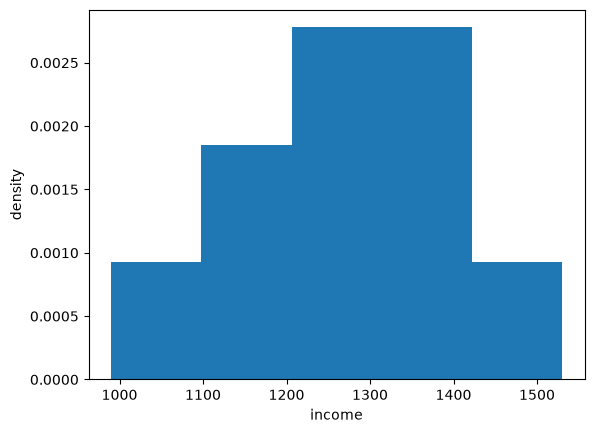

In [17]:
fig, ax = plt.subplots()
ax.hist(x, bins=5, density=True, histtype='bar')
ax.set_xlabel('income')
ax.set_ylabel('density')
plt.show()

以下是艾姆斯（Ames）房价的直方图。

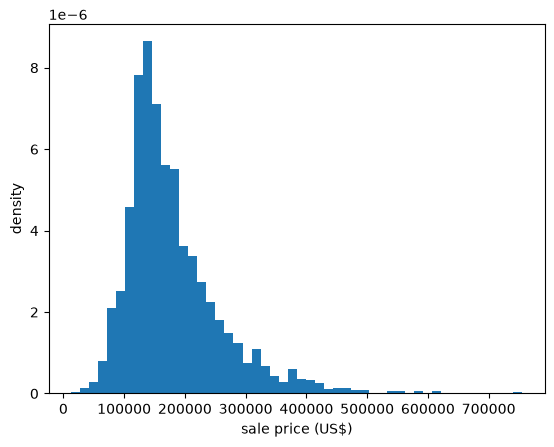

In [18]:
fig, ax = plt.subplots()
ax.hist(price, bins=50, density=True)
ax.set_xlabel('sale price (US$)')
ax.set_ylabel('density')
plt.show()

偏度所告诉我们的长右尾清晰可见。

让我们将其与对数价格的直方图进行比较。

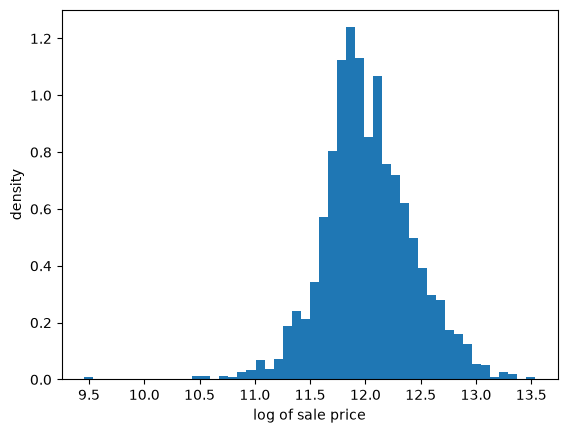

In [19]:
fig, ax = plt.subplots()
ax.hist(log_price, bins=50, density=True)
ax.set_xlabel('log of sale price')
ax.set_ylabel('density')
plt.show()

第二个直方图对称得多，这与样本偏度所预示的结果一致。

以下是死亡年龄数据，我们发现它具有负偏度。

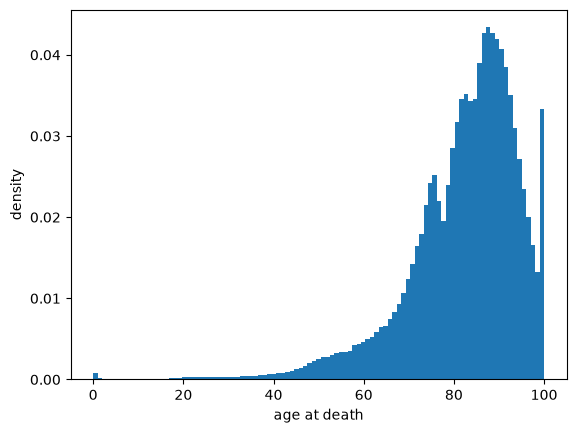

In [20]:
fig, ax = plt.subplots()
ax.hist(age_at_death, bins=101, density=True)
ax.set_xlabel('age at death')
ax.set_ylabel('density')
plt.show()

现在长尾向左延伸，朝向零。

让我们也利用数据集中特定性别的计数，比较男性和女性。

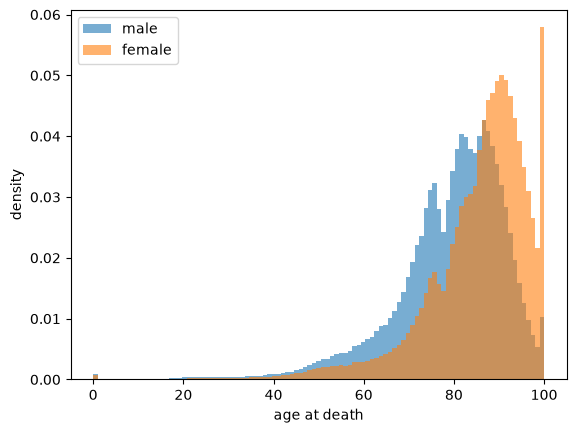

In [21]:
fig, ax = plt.subplots()
for sex in ('male', 'female'):
    ax.hist(deaths['age'], weights=deaths[f'deaths_{sex}'], 
            bins=101, density=True, alpha=0.6, label=sex)
ax.set_xlabel('age at death')
ax.set_ylabel('density')
ax.legend()
plt.show()

两个分布形状相似，但女性分布位于男性分布的右侧。

男性的死亡年龄中位数为 82 岁，女性为 88 岁。

右端的尖峰是上面讨论的"100 岁及以上"类别，这一类别在女性中要大得多。

（请注意，这里我们不需要展开计数，因为 `hist` 可以直接接受计数作为权重。）

让我们再看一个来自真实数据的分布。

具体来说，我们将查看 2000 年 1 月 1 日至 2024 年 1 月 1 日期间亚马逊（Amazon）股票的月度回报率。

月度回报率是根据每月股价的百分比变化计算的。

因此，每个月我们都会有一个观测值。

In [22]:
df = yf.download('AMZN', '2000-1-1', '2024-1-1', interval='1mo')
prices = df['Close']
x_amazon = prices.pct_change()[1:] * 100
x_amazon.head()

[*********************100%***********************]  1 of 1 completed


Ticker,AMZN
Date,
2000-02-01,6.679568
2000-03-01,-2.722323
2000-04-01,-17.630592
2000-05-01,-12.457531
2000-06-01,-24.838297


第一个观测值是 2000 年 1 月的月度回报率（百分比变化），为

In [23]:
x_amazon.iloc[0]

Ticker
AMZN    6.679568
Name: 2000-02-01 00:00:00, dtype: float64

让我们将回报率观测值转换为数组并绘制直方图。

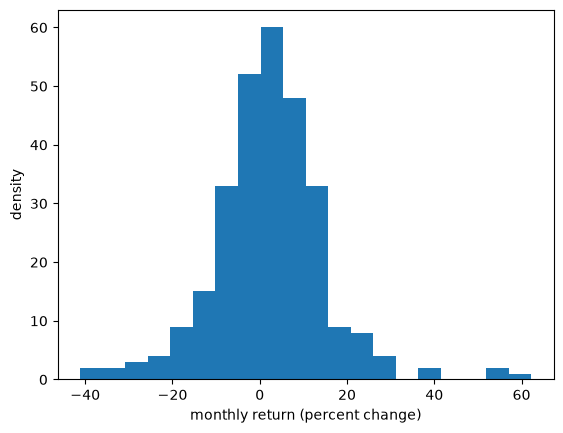

In [24]:
fig, ax = plt.subplots()
ax.hist(x_amazon, bins=20)
ax.set_xlabel('monthly return (percent change)')
ax.set_ylabel('density')
plt.show()

### 经验累积分布函数

直方图估计的是数据的密度。

**经验累积分布函数**（ECDF）对 CDF 做了同样的工作。

对于样本 $\{x_1, \ldots, x_n\}$，其定义为

$$
F_n(x) = \frac{1}{n} \sum_{i=1}^n \mathbb 1 \{x_i \leq x\}
$$

换句话说，$F_n(x)$ 就是小于或等于 $x$ 的观测值所占的比例。

ECDF 是一个阶梯函数，在每个观测值处向上跳跃 $1/n$。

以下是一个绘制 ECDF 的函数，通过对数据排序并从左到右逐步上升来实现。

In [25]:
def plot_ecdf(sample, ax, **kwargs):
    x_sorted = np.sort(sample)
    n = len(x_sorted)
    ax.step(x_sorted, np.arange(1, n+1) / n, where='post', **kwargs)

让我们将其应用于房价数据。

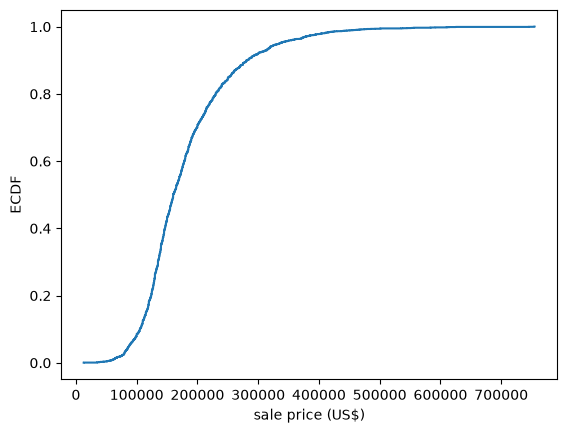

In [26]:
fig, ax = plt.subplots()
plot_ecdf(price, ax)
ax.set_xlabel('sale price (US$)')
ax.set_ylabel('ECDF')
plt.show()

与直方图不同，ECDF 不需要选择区间宽度——它完全按照数据原本的样子使用数据。

这使它成为比较数据集与概率分布的良好工具，因为我们可以简单地将两条曲线绘制在同一坐标轴上。

让我们将对数价格与具有相同均值和标准差的正态分布的 CDF 进行比较。

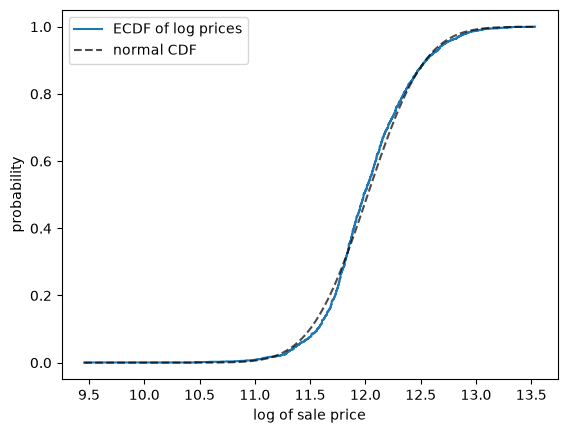

In [27]:
u = scipy.stats.norm(log_price.mean(), log_price.std())
x_grid = np.linspace(log_price.min(), log_price.max(), 200)

fig, ax = plt.subplots()
plot_ecdf(log_price, ax, label='ECDF of log prices')
ax.plot(x_grid, u.cdf(x_grid), 'k--', alpha=0.7, label='normal CDF')
ax.set_xlabel('log of sale price')
ax.set_ylabel('probability')
ax.legend()
plt.show()

两条曲线很接近，尽管拟合并不完美。

（Seaborn 提供了 `sns.ecdfplot`，可以用更少的代码生成相同的图形。）


### 核密度估计

核密度估计（KDE）提供了一种估计和可视化分布密度的简单方法。

如果你不熟悉 KDE，可以将其视为经过平滑处理的直方图。

让我们看一下由亚马逊回报率数据生成的 KDE。

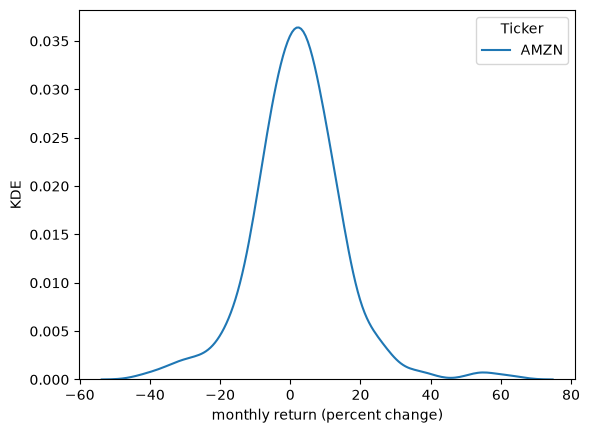

In [28]:
fig, ax = plt.subplots()
sns.kdeplot(x_amazon, ax=ax)
ax.set_xlabel('monthly return (percent change)')
ax.set_ylabel('KDE')
plt.show()

KDE 的平滑程度取决于我们如何选择带宽。

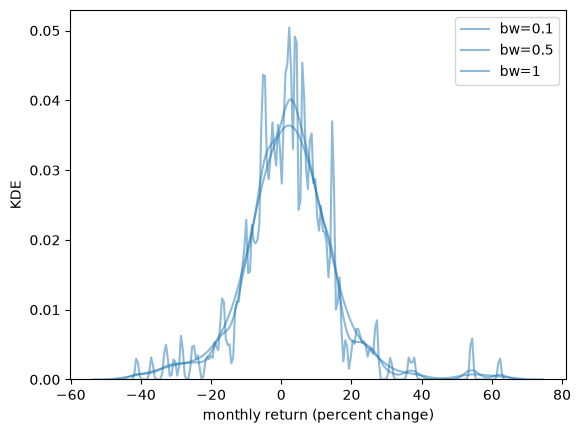

In [29]:
fig, ax = plt.subplots()
sns.kdeplot(x_amazon, ax=ax, bw_adjust=0.1, alpha=0.5, label="bw=0.1")
sns.kdeplot(x_amazon, ax=ax, bw_adjust=0.5, alpha=0.5, label="bw=0.5")
sns.kdeplot(x_amazon, ax=ax, bw_adjust=1, alpha=0.5, label="bw=1")
ax.set_xlabel('monthly return (percent change)')
ax.set_ylabel('KDE')
plt.legend()
plt.show()

当我们使用较大的带宽时，KDE 会更平滑。

一个合适的带宽既不能太平滑（欠拟合），也不能太曲折（过拟合）。

由于 KDE 是经过平滑处理的直方图，将两者一起展示通常会很有帮助。

以下是对数销售价格数据，直方图以淡化的形式呈现在背景中。

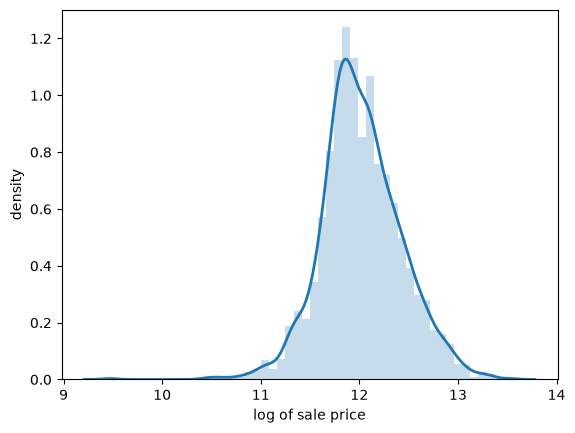

In [30]:
fig, ax = plt.subplots()
ax.hist(log_price, bins=50, density=True, alpha=0.25, color='C0')
sns.kdeplot(log_price, ax=ax, color='C0', lw=2)
ax.set_xlabel('log of sale price')
ax.set_ylabel('density')
plt.show()

KDE 描绘出了直方图的形状，同时平滑掉了区间间的波动。


### 箱线图

箱线图（或称箱须图）使用上面讨论过的样本分位数来概括一个分布。

箱体跨越第一和第三四分位数，因此其宽度是四分位距，而箱体内的线是中位数。

须线延伸至位于箱体 1.5 倍四分位距范围内的最极端观测值，超出这一范围的观测值则被单独绘制出来。

箱线图舍弃了大量信息，这使它非常适合同时比较多个组。

例如，让我们比较不同卧室数量的房屋的价格。

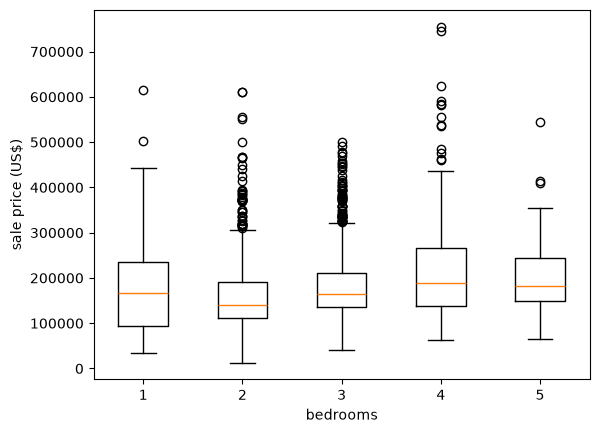

In [31]:
bedroom_counts = (1, 2, 3, 4, 5)
groups = [price[houses['bedrooms'] == b] for b in bedroom_counts]

fig, ax = plt.subplots()
ax.boxplot(groups, tick_labels=bedroom_counts)
ax.set_xlabel('bedrooms')
ax.set_ylabel('sale price (US$)')
plt.show()

这张图对过度解读组间平均值提出了警示。

四卧室房屋的售价确实高于三卧室房屋，但一卧室房屋的中位价格却*高于*两卧室房屋。

此外，每组内部的离散程度远大于组间的差异。

显然，卧室数量对房价的解释力相对较弱。

还请注意，单独绘制的点几乎全部位于须线之上，而不是之下。

这再次体现了右偏，现在逐组可见。

```{exercise}
:label: obs_ex2

数据集还记录了每套房屋的建筑面积（单位：平方英尺），存于 `living_area_sqft` 列中。

将房屋按建筑面积分成四个人数相等的组（Pandas 函数 `qcut` 可以帮你完成这一操作），并为每组绘制销售价格的箱线图。

建筑面积是否比卧室数量更能预测价格？
```

```{solution-start} obs_ex2
:class: dropdown
```

以下是一种解法：

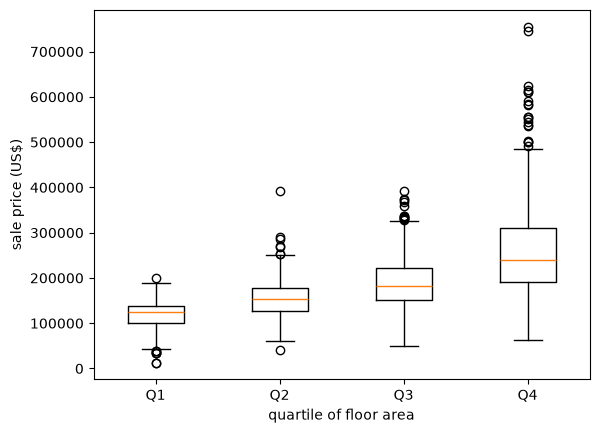

In [32]:
area_quartile = pd.qcut(houses['living_area_sqft'], 4, 
                        labels=['Q1', 'Q2', 'Q3', 'Q4'])
groups = [price[area_quartile == q] for q in ('Q1', 'Q2', 'Q3', 'Q4')]

fig, ax = plt.subplots()
ax.boxplot(groups, tick_labels=['Q1', 'Q2', 'Q3', 'Q4'])
ax.set_xlabel('quartile of floor area')
ax.set_ylabel('sale price (US$)')
plt.show()

现在中位数从一组到下一组稳步上升，且各组之间的差距相对于组内离散程度而言较大。

建筑面积显然是更好的预测因子。

```{solution-end}
```


(violin_plots)=
### 小提琴图


另一种展示观测分布的方法是通过小提琴图。

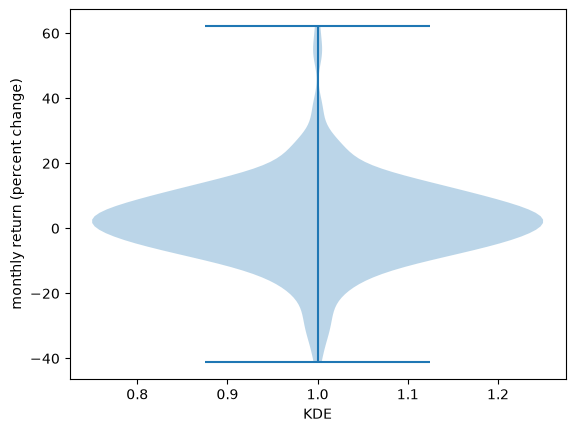

In [33]:
fig, ax = plt.subplots()
ax.violinplot(x_amazon)
ax.set_ylabel('monthly return (percent change)')
ax.set_xlabel('KDE')
plt.show()

当我们想要比较不同的分布时，小提琴图特别有用。

例如，让我们比较亚马逊股票的月度回报率与好市多（Costco）股票的月度回报率。

In [34]:
df = yf.download('COST', '2000-1-1', '2024-1-1', interval='1mo')
prices = df['Close']
x_costco = prices.pct_change()[1:] * 100

[*********************100%***********************]  1 of 1 completed


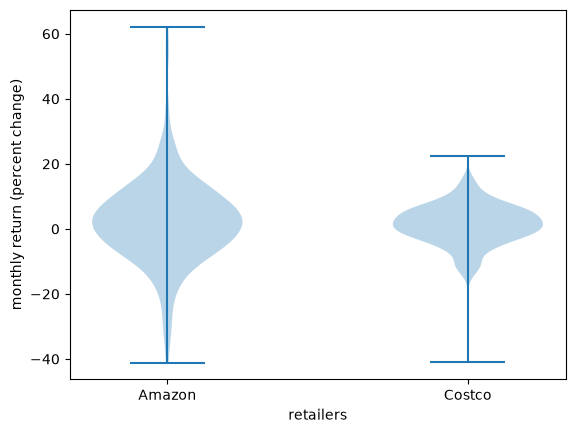

In [35]:
fig, ax = plt.subplots()
ax.violinplot([x_amazon['AMZN'], x_costco['COST']])
ax.set_ylabel('monthly return (percent change)')
ax.set_xlabel('retailers')

ax.set_xticks([1, 2])
ax.set_xticklabels(['Amazon', 'Costco'])
plt.show()

作为第二个比较，让我们回到死亡年龄数据，将男性和女性分开。

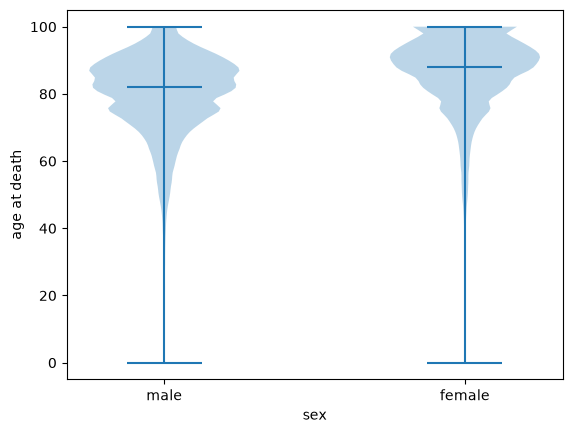

In [36]:
male_deaths = np.repeat(deaths['age'], deaths['deaths_male'])
female_deaths = np.repeat(deaths['age'], deaths['deaths_female'])

fig, ax = plt.subplots()
ax.violinplot([male_deaths, female_deaths], showmedians=True)
ax.set_ylabel('age at death')
ax.set_xlabel('sex')

ax.set_xticks([1, 2])
ax.set_xticklabels(['male', 'female'])
plt.show()

小提琴图展示了每个分布的完整形状，而不是箱线图将其简化成的五个数字。

这里这一点很重要：两个分布都强烈左偏，年轻时死亡的比例很小，形成一条细尾，而女性分布不仅向上移动，还在上端更为集中。

## 与概率分布的联系

让我们讨论观测分布与概率分布之间的联系。

有时假想一个观测分布是由某个特定的概率分布生成的会很有帮助。

例如，我们可能会查看上面亚马逊的回报率，并设想它们是由正态分布生成的。

（尽管这并非事实，但这*可能*是思考数据的一种有用方式。）

在这里，我们通过将样本均值设为正态分布的均值，并将样本方差设为正态分布的方差，将正态分布与亚马逊月度回报率相匹配。

（这个方法被称为矩方法，{doc}`fitting_distributions` 将对其进行完整的阐述。）

然后我们绘制密度函数和直方图。

In [37]:
μ = x_amazon.mean()
σ_squared = x_amazon.var()
σ = np.sqrt(σ_squared)
u = scipy.stats.norm(μ, σ)

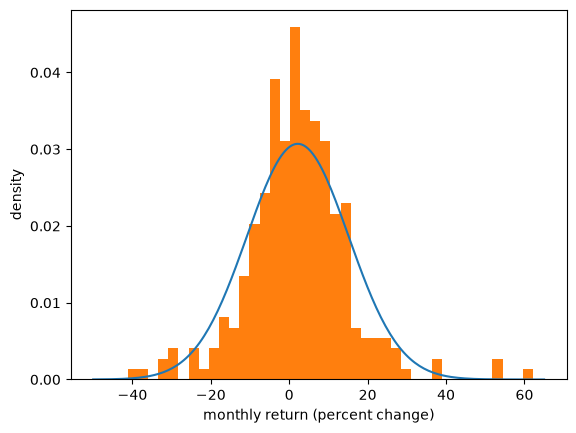

In [38]:
x_grid = np.linspace(-50, 65, 200)
fig, ax = plt.subplots()
ax.plot(x_grid, u.pdf(x_grid))
ax.hist(x_amazon, density=True, bins=40)
ax.set_xlabel('monthly return (percent change)')
ax.set_ylabel('density')
plt.show()

直方图和密度函数之间的匹配还算不错，但也不算很好。

原因之一是正态分布其实并不能很好地拟合这个观测数据——我们在讨论 {ref}`重尾分布 <heavy_tail>` 时会再次谈到这一点。

当然，如果数据*确实*是由正态分布生成的，那么拟合效果会更好。

让我们来看看这一点

- 首先我们从正态分布中生成随机抽样
- 然后我们对其作直方图并与密度函数进行比较。

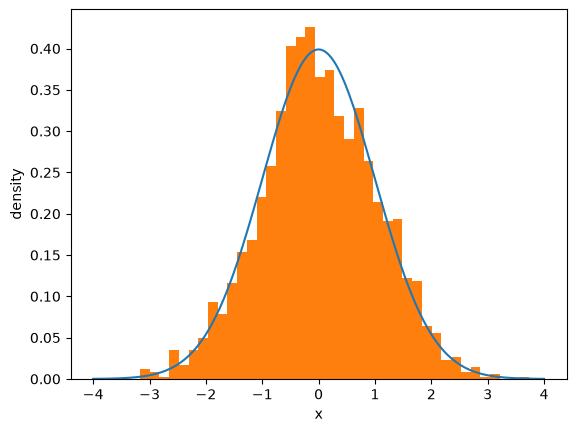

In [39]:
μ, σ = 0, 1
u = scipy.stats.norm(μ, σ)
N = 2000  # Number of observations
x_draws = u.rvs(N)
x_grid = np.linspace(-4, 4, 200)
fig, ax = plt.subplots()
ax.plot(x_grid, u.pdf(x_grid))
ax.hist(x_draws, density=True, bins=40)
ax.set_xlabel('x')
ax.set_ylabel('density')
plt.show()

请注意，如果你不断增加 $N$，即观测值的数量，拟合效果会越来越好。

我们将在下一节中研究这种收敛性。


## 更大的样本

在本讲座中，我们一直使用观测数据来说明某个潜在分布的一些性质。

只有当更大的样本能告诉我们更多信息时，这种方法才有效。

让我们使用 ECDF 来验证这一点确实成立，因为它能估计 CDF 而无需选择区间宽度或带宽。

我们从一个固定分布中抽取规模不断增大的样本，并将每个 ECDF 与生成它的 CDF 进行比较。

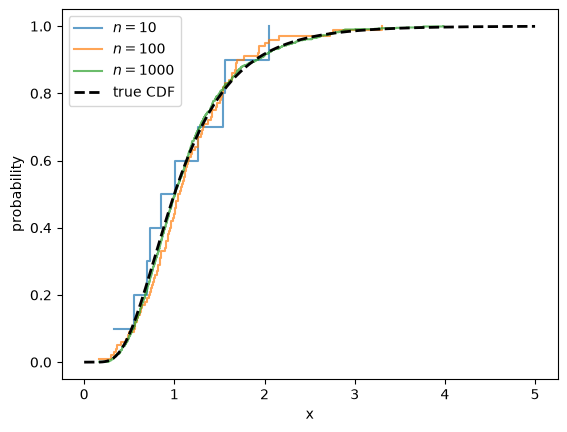

In [40]:
u = scipy.stats.lognorm(s=0.5)
x_grid = np.linspace(0, 5, 200)

fig, ax = plt.subplots()
for n in (10, 100, 1000):
    plot_ecdf(u.rvs(n, random_state=1234), ax, alpha=0.7, label=f'$n = {n}$')
ax.plot(x_grid, u.cdf(x_grid), 'k--', lw=2, label='true CDF')
ax.set_xlabel('x')
ax.set_ylabel('probability')
ax.legend()
plt.show()

当 $n = 10$ 时，ECDF 十分粗糙，而当 $n = 1000$ 时，它已经几乎与真实的 CDF 无法区分。

样本矩的表现方式相同。

In [41]:
for n in (10, 100, 1000, 1_000_000):
    x_draws = u.rvs(n, random_state=1234)
    print(f'n = {n:>9,}:  sample mean = {x_draws.mean():.4f}')
print(f'{"":16}population mean = {u.mean():.4f}')

n =        10:  sample mean = 1.0573
n =       100:  sample mean = 1.1398
n =     1,000:  sample mean = 1.1340
n = 1,000,000:  sample mean = 1.1332
                population mean = 1.1331


这种收敛性是*大数定律*的一个体现，我们将在 {doc}`lln_clt` 中讨论这一点。


### 独立性的作用

上述的收敛并非自动发生的。

它取决于样本的一个容易被忽视的性质，因为 `rvs` 默默地提供了这个性质：它返回的抽样是**独立的**。

为了说明这一点为何重要，假设我们从分布中抽取单个样本 $X$，然后设定

$$
X_i = X
\qquad \text{对 } i = 1, \ldots, n
$$

现在每个 $X_i$ 都恰好具有正确的分布。

单独来看，这些都是完全合格的观测值。

但作为样本，它们毫无用处，如下图所示。

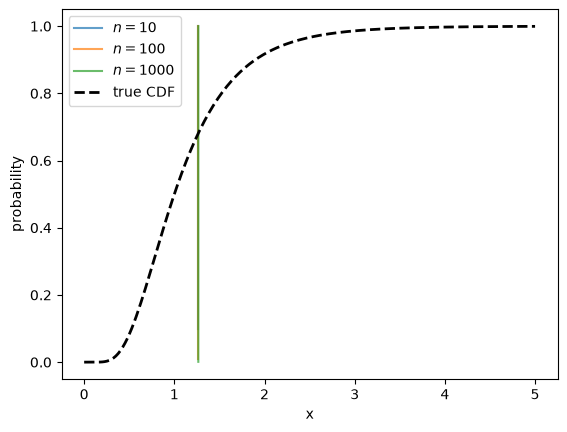

In [42]:
x = u.rvs(random_state=1234)         # a single draw

fig, ax = plt.subplots()
for n in (10, 100, 1000):
    x_draws = np.full(n, x)          # repeated n times
    plot_ecdf(x_draws, ax, alpha=0.7, label=f'$n = {n}$')
ax.plot(x_grid, u.cdf(x_grid), 'k--', lw=2, label='true CDF')
ax.set_xlabel('x')
ax.set_ylabel('probability')
ax.legend()
plt.show()

三条 ECDF 完全重叠在一起：每条都是在 $X$ 处的一个单一阶梯，增加 $n$ 并不会改变任何东西。

无论我们把样本规模做得多大，样本都不会逼近其来源的分布。

原因在于，第一个观测值之后的所有观测值都没有带来我们尚未掌握的信息。

```{note}
独立性是一个简洁的充分条件，而非必要条件。

许多相依样本也能很好地发挥作用——我们上面绘制的月度回报率直方图当然不是独立的，因为波动大的月份往往紧随着波动大的月份。

真正重要的是，新的观测值要不断带来新的信息，而上面的例子则完全破坏了这一点。

关于样本能告诉我们关于其分布的哪些信息这一一般性问题，将在 {doc}`lln_clt` 中讨论。
```